In [2]:
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("C:\\Users\\91917\\Desktop\\Datasets\\salaries.csv")
df

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0
5,google,computer programmer,masters,1
6,abc pharma,sales executive,masters,0
7,abc pharma,computer programmer,bachelors,0
8,abc pharma,business manager,bachelors,0
9,abc pharma,business manager,masters,1


In [9]:
#step 2: Encode categorical data 

label_encoders ={}
for column in ["company","job","degree"]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [29]:
label_encoders

{'company': LabelEncoder(), 'job': LabelEncoder(), 'degree': LabelEncoder()}

In [31]:
X

,company,job,degree
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [11]:
#features and target
X = df[["company","job","degree"]]
y = df["salary_more_then_100k"]

In [35]:
#step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
#step 4: Train the decision tree classifier
clf = DecisionTreeClassifier(criterion="gini",random_state=42) # two ways of dt gini and entropy 
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

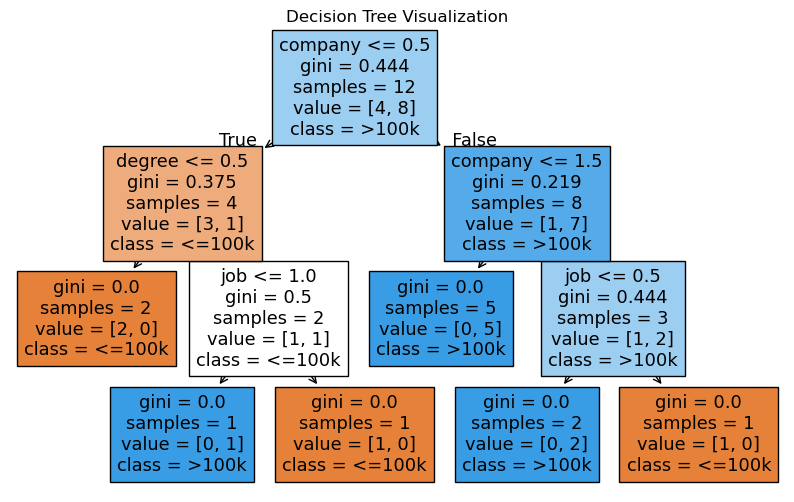

In [39]:
# step 5 : visualize the decision tree 
plt.figure(figsize=(10,6))
plot_tree(clf, feature_names=["company","job","degree"],class_names=["<=100k",">100k"],filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [41]:
# step 6: Display the tree in text format
tree_rules = export_text(clf, feature_names=["company","job","degree"])
print(tree_rules)

|--- company <= 0.50
|   |--- degree <= 0.50
|   |   |--- class: 0
|   |--- degree >  0.50
|   |   |--- job <= 1.00
|   |   |   |--- class: 1
|   |   |--- job >  1.00
|   |   |   |--- class: 0
|--- company >  0.50
|   |--- company <= 1.50
|   |   |--- class: 1
|   |--- company >  1.50
|   |   |--- job <= 0.50
|   |   |   |--- class: 1
|   |   |--- job >  0.50
|   |   |   |--- class: 0



In [43]:
# Step 7: Predict on new data
new_data = [[0,1,1]] #ex: company=google, job=buiseness manager , degree=masters
prediction = clf.predict(new_data)
print(f"Predicted salary category: {'<100k' if prediction[0] == 1 else '<=100k'}")

Predicted salary category: <100k


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
